In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

dataset_path = r"C:\Users\ASUS TUF\Downloads\Dataset .csv"
df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully
Rows: 9551
Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [3]:
df.isnull().sum

<bound method DataFrame.sum of       Restaurant ID  Restaurant Name  Country Code   City  Address  Locality  \
0             False            False         False  False    False     False   
1             False            False         False  False    False     False   
2             False            False         False  False    False     False   
3             False            False         False  False    False     False   
4             False            False         False  False    False     False   
...             ...              ...           ...    ...      ...       ...   
9546          False            False         False  False    False     False   
9547          False            False         False  False    False     False   
9548          False            False         False  False    False     False   
9549          False            False         False  False    False     False   
9550          False            False         False  False    False     False   

      Lo

#  Level 1 - Task 1: Top Cuisines
# Determine the top three most common cuisines and calculate the percentage of restaurants serving each cuisine.

In [4]:
cuisines = df['Cuisines'].dropna().str.split(',').explode().str.strip()

top_cuisines = cuisines.value_counts().head(3)
top_cuisines_percentage = (top_cuisines / len(df) * 100).round(2)

top_cuisine_result = pd.DataFrame({
    'Restaurant Count': top_cuisines,
    'Percentage of Restaurants': top_cuisines_percentage
})

top_cuisine_result

,Restaurant Count,Percentage of Restaurants
Cuisines,,
North Indian,3960,41.46
Chinese,2735,28.64
Fast Food,1986,20.79


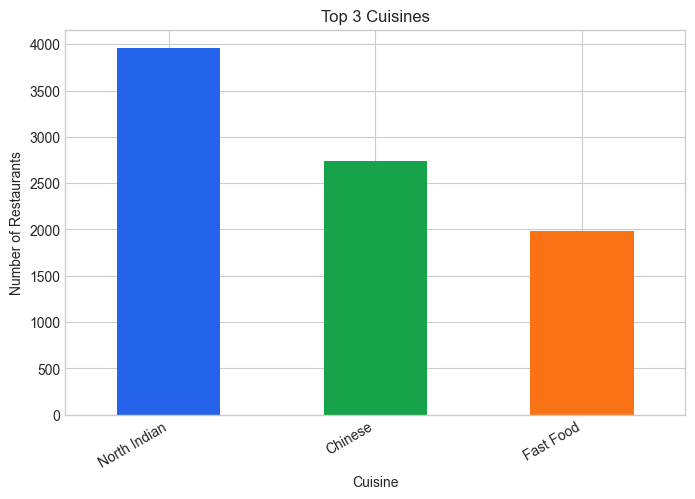

In [5]:
plt.figure(figsize=(8, 5))
top_cuisines.plot(kind='bar', color=['#2563eb', '#16a34a', '#f97316'])
plt.title('Top 3 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=30, ha='right')
plt.show()

#  Level 1 - Task 2: City Analysis
# Identify the city with the highest number of restaurants, calculate average rating by city, and determine the city with the highest average rating.

In [9]:
city_counts = df['City'].value_counts()
city_average_ratings = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)


In [10]:
city_with_most_restaurants = city_counts.idxmax()
highest_restaurant_count = city_counts.max()


In [11]:
city_with_highest_avg_rating = city_average_ratings.idxmax()
highest_avg_rating = city_average_ratings.max()

print(f"City with highest number of restaurants: {city_with_most_restaurants} ({highest_restaurant_count} restaurants)")
print(f"City with highest average rating: {city_with_highest_avg_rating} ({highest_avg_rating:.2f})")

City with highest number of restaurants: New Delhi (5473 restaurants)
City with highest average rating: Inner City (4.90)


In [12]:
# Top 10 cities by restaurant count
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

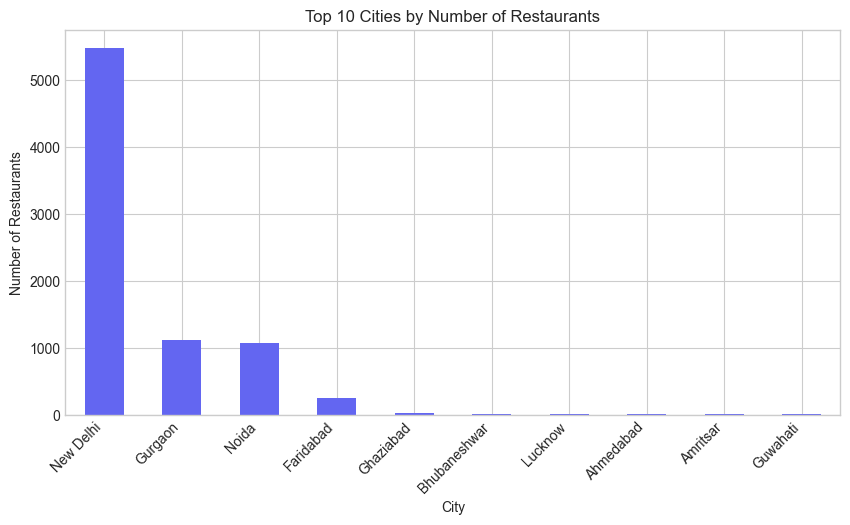

In [13]:
plt.figure(figsize=(10, 5))
city_counts.head(10).plot(kind='bar', color='#6366f1')
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
# Top 10 cities by average rating
city_average_ratings.head(10).round(2)

City
Inner City          4.90
Quezon City         4.80
Makati City         4.65
Pasig City          4.63
Mandaluyong City    4.62
Beechworth          4.60
London              4.54
Taguig City         4.53
Secunderabad        4.50
Lincoln             4.50
Name: Aggregate rating, dtype: float64

# Level 1 - Task 3: Price Range Distribution
# Create a bar chart for price ranges and calculate the percentage of restaurants in each category.

In [16]:
price_counts = df['Price range'].value_counts().sort_index()
price_percentages = (price_counts / len(df) * 100).round(2)

price_range_result = pd.DataFrame({
    'Restaurant Count': price_counts,
    'Percentage': price_percentages
})

price_range_result

,Restaurant Count,Percentage
Price range,,
1,4444,46.53
2,3113,32.59
3,1408,14.74
4,586,6.14


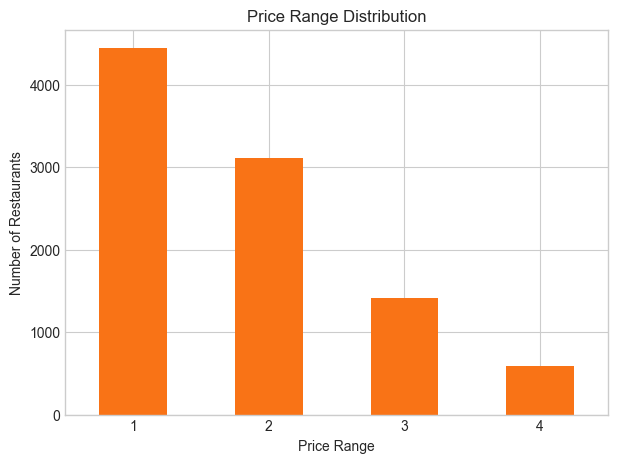

In [17]:
plt.figure(figsize=(7, 5))
price_counts.plot(kind='bar', color='#f97316')
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.show()

# Level 1 - Task 4: Online Delivery
# Determine the percentage of restaurants offering online delivery and compare average ratings with and without online delivery.

In [18]:
online_delivery_percentage = (df['Has Online delivery'].str.lower() == 'yes').mean() * 100
rating_by_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean().round(2)

print(f"Percentage of restaurants offering online delivery: {online_delivery_percentage:.2f}%")
rating_by_delivery

Percentage of restaurants offering online delivery: 25.66%


Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64

# Level 2 - Task 1: Restaurant Ratings
# Analyze the distribution of aggregate ratings, determine the most common rating range, and calculate average votes.

In [19]:
rating_bins = [-0.01, 1, 2, 3, 4, 5]
rating_labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

df['Rating Range'] = pd.cut(df['Aggregate rating'], bins=rating_bins, labels=rating_labels)
rating_distribution = df['Rating Range'].value_counts().sort_index()

most_common_rating_range = rating_distribution.idxmax()
average_votes = df['Votes'].mean()

print(f"Most common rating range: {most_common_rating_range}")
print(f"Average number of votes: {average_votes:.2f}")
rating_distribution

Most common rating range: 3-4
Average number of votes: 156.91


Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64

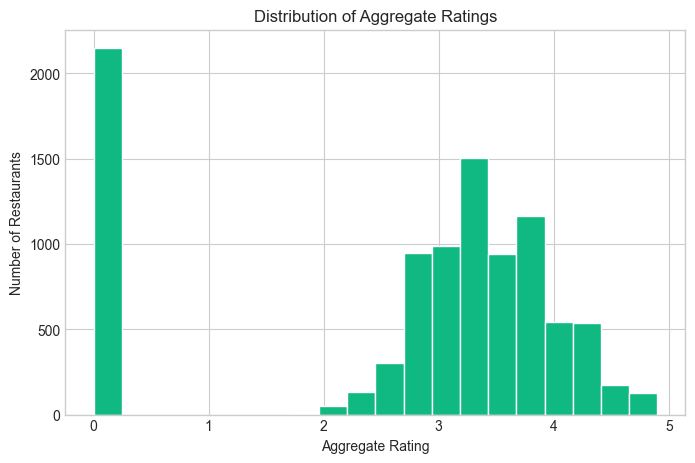

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df['Aggregate rating'], bins=20, color='#10b981', edgecolor='white')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.show()

# Level 2 - Task 2: Cuisine Combination
# Identify common cuisine combinations and check which combinations tend to have higher ratings.

In [21]:
common_cuisine_combinations = df['Cuisines'].dropna().value_counts().head(10)
common_cuisine_combinations

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [22]:
cuisine_combination_ratings = (
    df.dropna(subset=['Cuisines'])
    .groupby('Cuisines')
    .agg(
        Restaurant_Count=('Restaurant ID', 'count'),
        Average_Rating=('Aggregate rating', 'mean'),
        Average_Votes=('Votes', 'mean')
    )
    .query('Restaurant_Count >= 5')
    .sort_values(['Average_Rating', 'Restaurant_Count'], ascending=[False, False])
    .head(10)
    .round(2)
)

cuisine_combination_ratings

,Restaurant_Count,Average_Rating,Average_Votes
Cuisines,,,
"North Indian, European, Mediterranean",5,4.46,1452.20
Burger,6,4.45,456.17
Modern Indian,11,4.35,1123.18
Indian,18,4.25,337.11
International,6,4.23,162.17
"Italian, Pizza, Sandwich",5,4.22,541.20
French,7,4.19,170.29
Steak,7,4.19,197.00
"Cafe, Bakery, Desserts",6,4.17,208.00


# Level 2 - Task 3: Geographic Analysis
# Plot restaurant locations using longitude and latitude coordinates.

In [23]:
geo_df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()

print(f"Restaurants with valid coordinates: {len(geo_df)}")
geo_df[['Restaurant Name', 'City', 'Latitude', 'Longitude', 'Aggregate rating']].head()

Restaurants with valid coordinates: 9052


,Restaurant Name,City,Latitude,Longitude,Aggregate rating
0,Le Petit Souffle,Makati City,14.565443,121.027535,4.8
1,Izakaya Kikufuji,Makati City,14.553708,121.014101,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,14.581404,121.056831,4.4
3,Ooma,Mandaluyong City,14.585318,121.056475,4.9
4,Sambo Kojin,Mandaluyong City,14.584450,121.057508,4.8


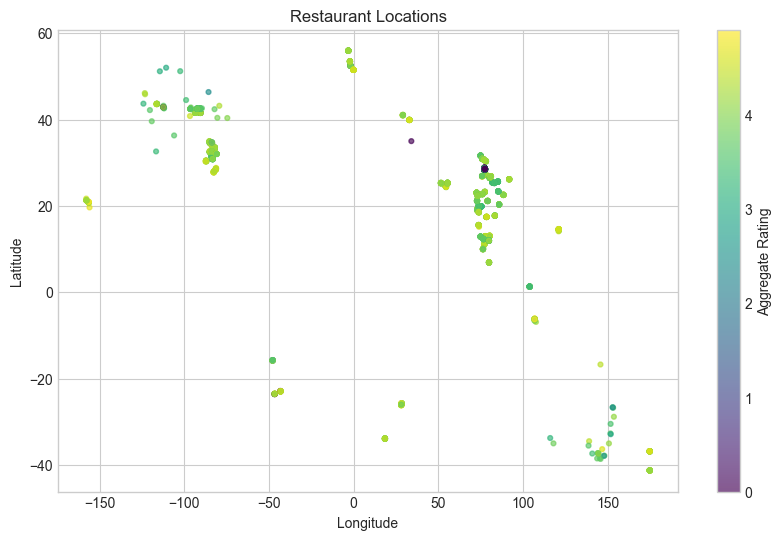

In [24]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    geo_df['Longitude'],
    geo_df['Latitude'],
    c=geo_df['Aggregate rating'],
    cmap='viridis',
    s=12,
    alpha=0.65
)
plt.colorbar(scatter, label='Aggregate Rating')
plt.title('Restaurant Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Level 2 - Task 4: Restaurant Chains
# Identify restaurant chains and analyze their ratings and popularity.
 

In [25]:
restaurant_chains = (
    df.groupby('Restaurant Name')
    .agg(
        Outlet_Count=('Restaurant ID', 'count'),
        Average_Rating=('Aggregate rating', 'mean'),
        Total_Votes=('Votes', 'sum'),
        Average_Votes=('Votes', 'mean')
    )
    .query('Outlet_Count > 1')
    .sort_values(['Outlet_Count', 'Total_Votes'], ascending=False)
    .round(2)
)

print(f"Number of restaurant chains found: {len(restaurant_chains)}")
restaurant_chains.head(15)

Number of restaurant chains found: 734


,Outlet_Count,Average_Rating,Total_Votes,Average_Votes
Restaurant Name,,,,
Cafe Coffee Day,83,2.42,2428,29.25
Domino's Pizza,79,2.74,6643,84.09
Subway,63,2.91,6124,97.21
Green Chick Chop,51,2.67,964,18.90
McDonald's,48,3.34,5291,110.23
Keventers,34,2.87,1263,37.15
Pizza Hut,30,3.32,4961,165.37
Giani,29,2.69,854,29.45
Baskin Robbins,28,1.86,428,15.29


# Level 3 - Task 1: Restaurant Reviews
# The provided dataset does not contain a text review/comment column. Because of that, positive/negative keyword analysis and review-length analysis cannot be completed from this CSV alone.

In [26]:
possible_review_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in ['review', 'comment', 'feedback', 'text'])
]

if possible_review_columns:
    print('Review columns found:', possible_review_columns)
else:
    print('No review/comment text columns are available in this dataset.')

Review columns found: ['Rating text']


# Level 3 - Task 2: Votes Analysis
# Identify restaurants with highest and lowest votes, and analyze correlation between votes and rating.

In [27]:
highest_votes_restaurant = df.loc[df['Votes'].idxmax()]
lowest_votes_restaurant = df.loc[df['Votes'].idxmin()]
votes_rating_correlation = df['Votes'].corr(df['Aggregate rating'])

print('Restaurant with highest votes:')
print(highest_votes_restaurant[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

print('\nRestaurant with lowest votes:')
print(lowest_votes_restaurant[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

print(f"\nCorrelation between votes and rating: {votes_rating_correlation:.3f}")

Restaurant with highest votes:
Restaurant Name          Toit
City                Bangalore
Votes                   10934
Aggregate rating          4.8
Name: 728, dtype: object

Restaurant with lowest votes:
Restaurant Name     Cantinho da Gula
City                      S��o Paulo
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object

Correlation between votes and rating: 0.314


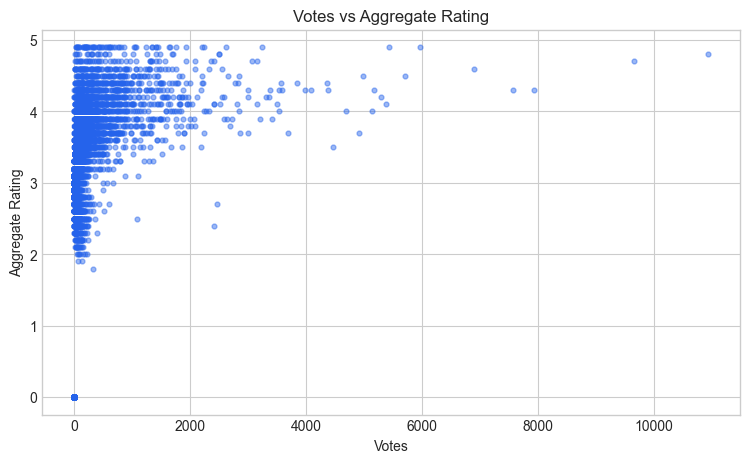

In [28]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Votes'], df['Aggregate rating'], alpha=0.45, s=12, color='#2563eb')
plt.title('Votes vs Aggregate Rating')
plt.xlabel('Votes')
plt.ylabel('Aggregate Rating')
plt.show()

# Level 3 - Task 3: Price Range vs Online Delivery and Table Booking
# Analyze whether higher-priced restaurants are more likely to offer online delivery and table booking.

In [29]:
online_delivery_by_price = (
    df.groupby('Price range')['Has Online delivery']
    .apply(lambda x: (x.str.lower() == 'yes').mean() * 100)
    .round(2)
)

table_booking_by_price = (
    df.groupby('Price range')['Has Table booking']
    .apply(lambda x: (x.str.lower() == 'yes').mean() * 100)
    .round(2)
)

services_by_price = pd.DataFrame({
    'Online Delivery Yes %': online_delivery_by_price,
    'Table Booking Yes %': table_booking_by_price
})

services_by_price

,Online Delivery Yes %,Table Booking Yes %
Price range,,
1,15.77,0.02
2,41.31,7.68
3,29.19,45.74
4,9.04,46.76


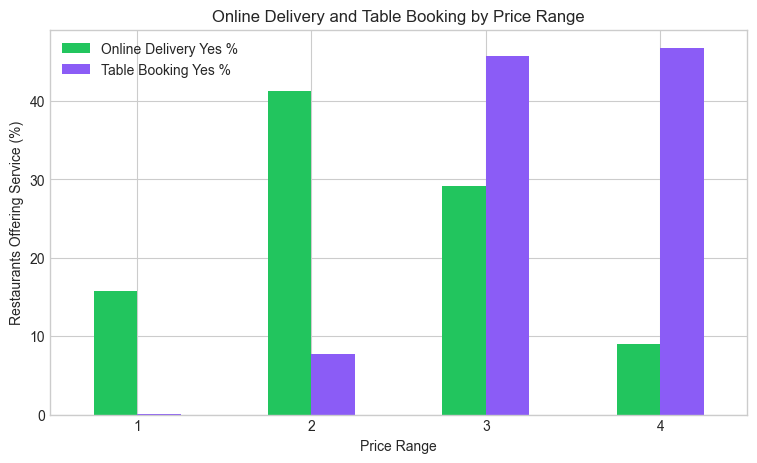

In [30]:
services_by_price.plot(kind='bar', figsize=(9, 5), color=['#22c55e', '#8b5cf6'])
plt.title('Online Delivery and Table Booking by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Restaurants Offering Service (%)')
plt.xticks(rotation=0)
plt.show()